# **1. Perkenalan Dataset**


Dataset yang digunakan pada proyek ini adalah dataset **Loan Approval Prediction** yang berisi informasi terkait profil peminjam dan status persetujuan pinjaman.

Dataset ini digunakan untuk membangun model machine learning klasifikasi yang dapat memprediksi apakah suatu pinjaman akan disetujui atau tidak berdasarkan atribut tertentu.

## Informasi Dataset

* Jumlah data: ±45.000 baris
* Jumlah fitur: 14 kolom
* Jenis masalah: Binary Classification
* Target: `loan_status`

## Sumber Dataset

Dataset diperoleh dari:

* Kaggle

## Tujuan Proyek

Tujuan dari proyek ini adalah:

1. Melakukan eksplorasi data (EDA)
2. Melakukan preprocessing data
3. Menyiapkan dataset untuk pelatihan model machine learning
4. Mengotomatisasi preprocessing untuk kebutuhan MLOps


# **2. Import Library**

In [23]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini dilakukan proses pemuatan dataset untuk memastikan data berhasil dibaca dengan baik sebelum dilakukan analisis lebih lanjut.


In [24]:
# Memuat data
df = pd.read_csv('../namadataset_raw/raw_data.csv')
print("Ukuran Dataset:", df.shape)
df.head()

Ukuran Dataset: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [25]:
df.shape

(45000, 14)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

# **4. Exploratory Data Analysis (EDA)**

Exploratory Data Analysis dilakukan untuk memahami karakteristik data, distribusi fitur, hubungan antar variabel, serta mendeteksi potensi masalah pada dataset.


In [27]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [28]:
df.duplicated().sum()

0

In [29]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


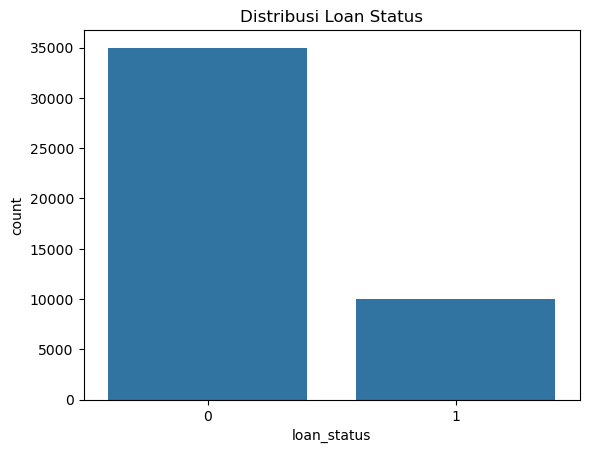

In [30]:
sns.countplot(x='loan_status', data=df)

plt.title('Distribusi Loan Status')
plt.show()

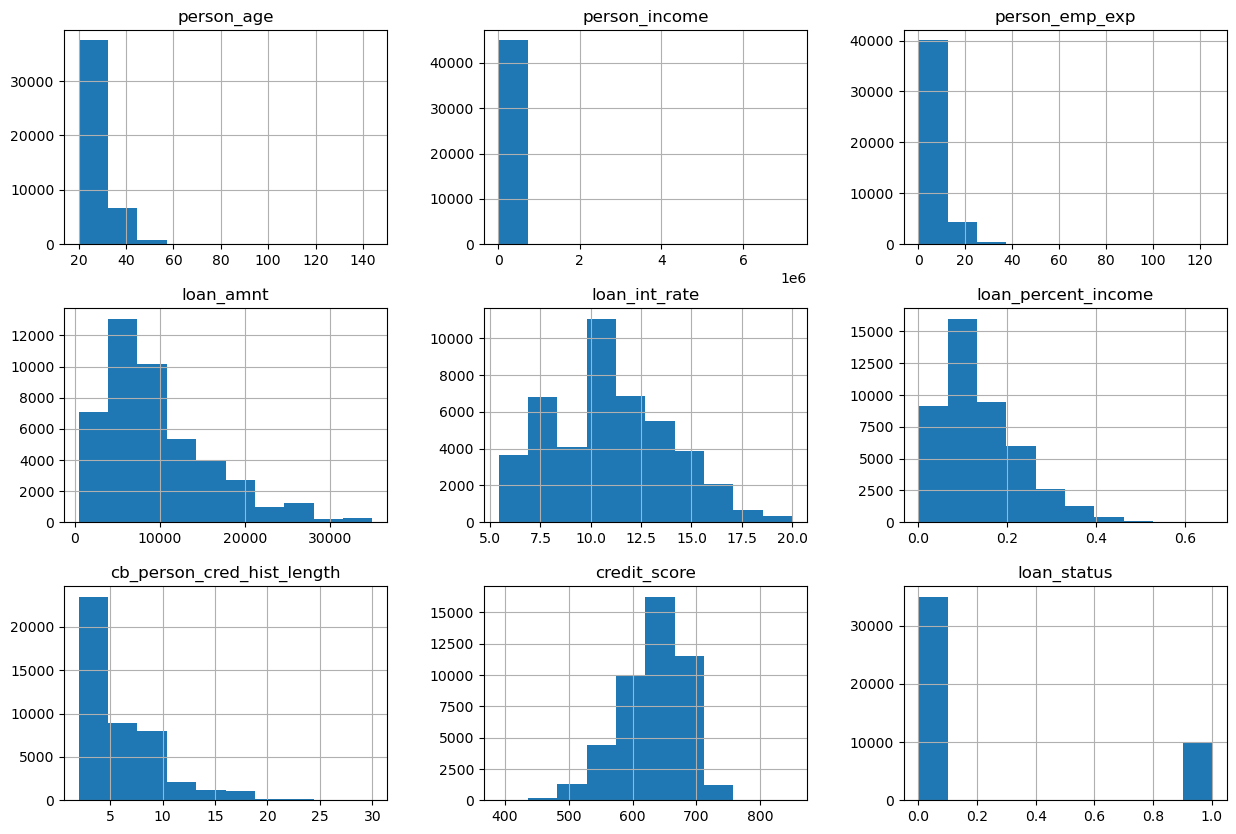

In [31]:
df.hist(figsize=(15,10))

plt.show()

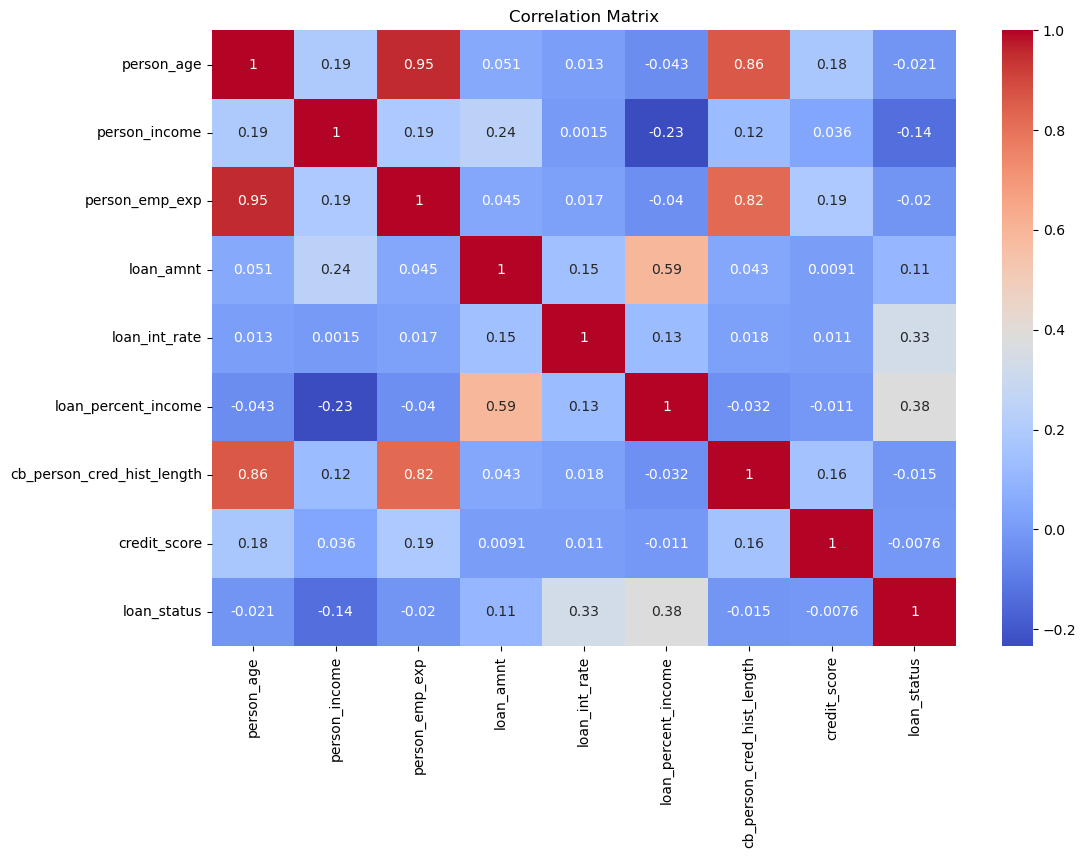

In [32]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

# **5. Data Preprocessing**

Tahap preprocessing dilakukan untuk membersihkan data dan mempersiapkan dataset agar dapat digunakan pada proses pelatihan model machine learning.


In [33]:
df = df.dropna()

In [34]:
df = df.drop_duplicates()

In [35]:
categorical_cols = df.select_dtypes(
    include='object'
).columns

categorical_cols

Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')

In [36]:
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [37]:
X = df.drop('loan_status', axis=1)

y = df['loan_status']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [40]:
import os

train_df = pd.DataFrame(X_train)

train_df['loan_status'] = y_train.reset_index(drop=True)

# Create the directory if it does not exist
output_dir = 'namadataset_preprocessing'
os.makedirs(output_dir, exist_ok=True)

train_df.to_csv(
    os.path.join(output_dir, 'loan_clean.csv'),
    index=False
)

print("Dataset preprocessing berhasil disimpan!")

Dataset preprocessing berhasil disimpan!
